# EDA on Retail Sales Data
## Objective
#To perform exploratory data analysis on a retail sales dataset to identify sales trends,
#customer behaviour, product performance, and actionable business insights.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv(r"D:\Intern\Retail Sales Dataset\realistic_e_commerce_sales_data.csv")
df.head()

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
0,CUST0268,Male,North,NaN,Monitor,Electronics,300.0,5,1500,13.31,Returned,2023-12-08
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.0,2,200,6.93,In Transit,2023-04-09
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.0,1,300,11.31,Returned,2023-08-28
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.0,5,500,12.22,Delivered,2023-01-18
4,CUST0173,Female,South,NaN,Laptop,Electronics,1500.0,3,4500,5.40,Delivered,2023-01-19


## 1. Initial Data Inspection

In [7]:
df.shape

(1000, 12)

In [8]:
df.columns

Index(['Customer ID', 'Gender', 'Region', 'Age', 'Product Name', 'Category',
       'Unit Price', 'Quantity', 'Total Price', 'Shipping Fee',
       'Shipping Status', 'Order Date'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer ID      1000 non-null   str    
 1   Gender           1000 non-null   str    
 2   Region           950 non-null    str    
 3   Age              900 non-null    float64
 4   Product Name     1000 non-null   str    
 5   Category         1000 non-null   str    
 6   Unit Price       1000 non-null   float64
 7   Quantity         1000 non-null   int64  
 8   Total Price      1000 non-null   int64  
 9   Shipping Fee     1000 non-null   float64
 10  Shipping Status  950 non-null    str    
 11  Order Date       1000 non-null   str    
dtypes: float64(3), int64(2), str(7)
memory usage: 93.9 KB


In [10]:
df.isnull().sum()

Customer ID          0
Gender               0
Region              50
Age                100
Product Name         0
Category             0
Unit Price           0
Quantity             0
Total Price          0
Shipping Fee         0
Shipping Status     50
Order Date           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
print('start date:',df['Order Date'].min())
print('end date:', df['Order Date'].max())
df.dtypes

start date: 2023-01-01 00:00:00
end date: 2024-01-03 00:00:00


Customer ID                   str
Gender                        str
Region                        str
Age                       float64
Product Name                  str
Category                      str
Unit Price                float64
Quantity                    int64
Total Price                 int64
Shipping Fee              float64
Shipping Status               str
Order Date         datetime64[us]
dtype: object

In [12]:
df.describe()

,Age,Unit Price,Quantity,Total Price,Shipping Fee,Order Date
count,900.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000
mean,46.695556,457.703777,3.008000,1346.600000,12.416390,2023-07-07 19:30:43.200000
min,18.000000,30.000000,1.000000,30.000000,5.000000,2023-01-01 00:00:00
25%,35.000000,50.000000,2.000000,200.000000,8.560000,2023-04-08 00:00:00
50%,49.000000,200.000000,3.000000,600.000000,12.315000,2023-07-12 12:00:00
75%,59.000000,800.000000,4.000000,1500.000000,16.075000,2023-10-12 18:00:00
max,69.000000,3109.560612,5.000000,7500.000000,19.980000,2024-01-03 00:00:00
std,15.011400,537.231434,1.404246,1834.037877,4.412185,NaN


In [13]:
analysis_cols=['Age','Unit Price','Quantity','Total Price','Shipping Fee',]
stats=pd.DataFrame({'Mean':df[analysis_cols].mean(),
                    'Median':df[analysis_cols].median(),
                    'Mode':df[analysis_cols].mode().iloc[0],
                    'Standard Deviation':df[analysis_cols].std()
                   })
stats.round(2)
print(stats.round(2))


                 Mean  Median    Mode  Standard Deviation
Age             46.70   49.00   66.00               15.01
Unit Price     457.70  200.00  300.00              537.23
Quantity         3.01    3.00    3.00                1.40
Total Price   1346.60  600.00  200.00             1834.04
Shipping Fee    12.42   12.32    9.26                4.41


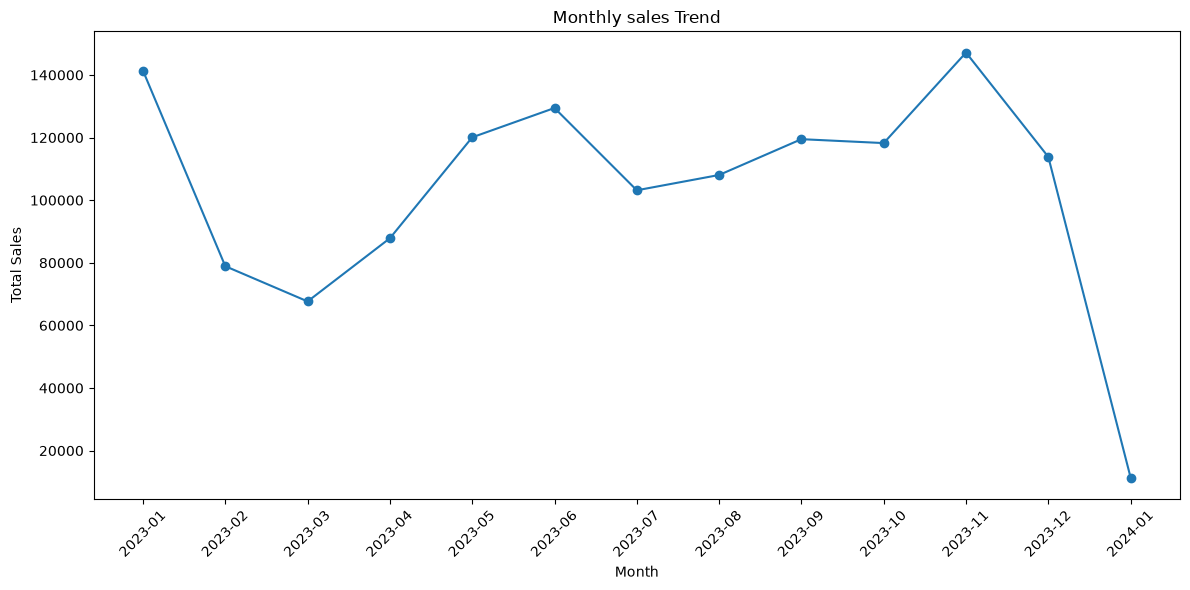

In [14]:
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Price'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o')
plt.title('Monthly sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation
Monthly sales fluctuate throughout the period. Sales reached their highest level in November, while March recorded the lowest sales.
This suggests possible seasonal variation in customer purchasing behaviour.

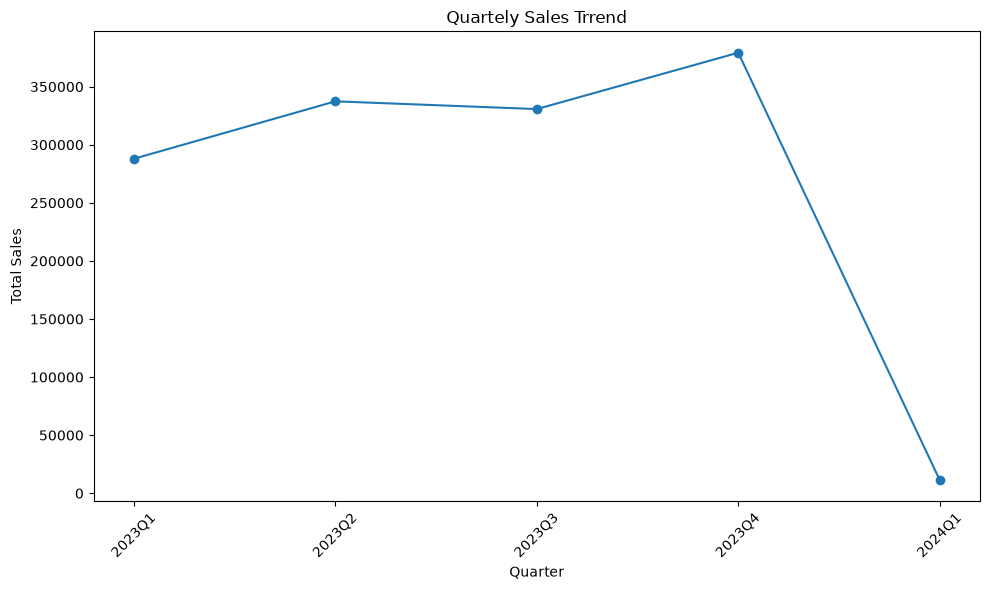

In [15]:
df['Quarter'] = df['Order Date'].dt.to_period('Q')
quartely_sales = df.groupby('Quarter')['Total Price'].sum()
quartely_sales.index = quartely_sales.index.astype(str)
plt.figure(figsize=(10,6))
plt.plot(quartely_sales.index,
         quartely_sales.values,
         marker='o')
plt.title('Quartely Sales Trrend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Observation
Quarterly sales show differences in revenue performance across the year.
The strongest quarter was Q4, suggesting higher customer spending during this period.

In [17]:
bins = [0, 20, 30, 40, 50, 60, 100]

labels = [
    'Under 20',
    '20-29',
    '30-39',
    '40-49',
    '50-59',
    '60+'
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False
)
df[['Age', 'Age Group']].head()

,Age,Age Group
0,NaN,NaN
1,22.0,20-29
2,54.0,50-59
3,23.0,20-29
4,NaN,NaN


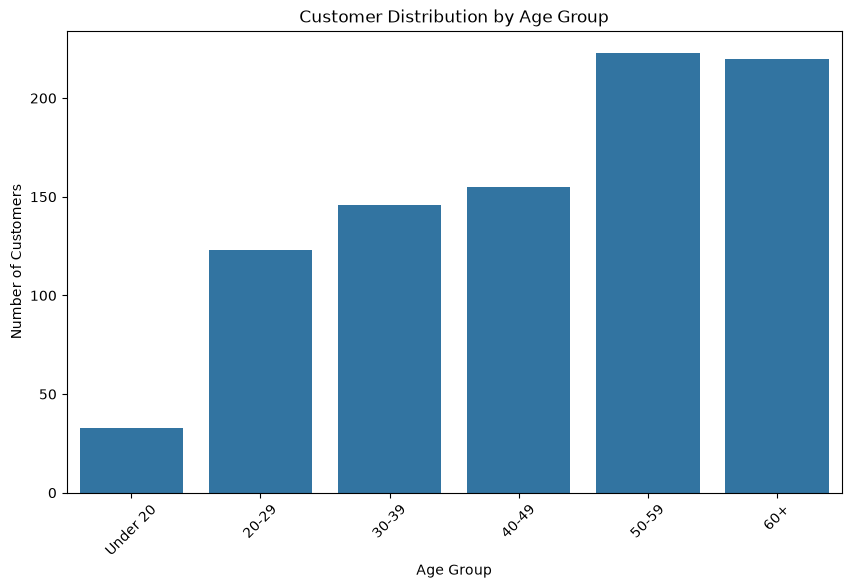

In [18]:
age_group_counts = df['Age Group'].value_counts().sort_index()
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='Age Group',
    order=labels
)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

### Observation
The largest customer segment is the 50-59 group, indicating that this age range represents an important target market for the business.

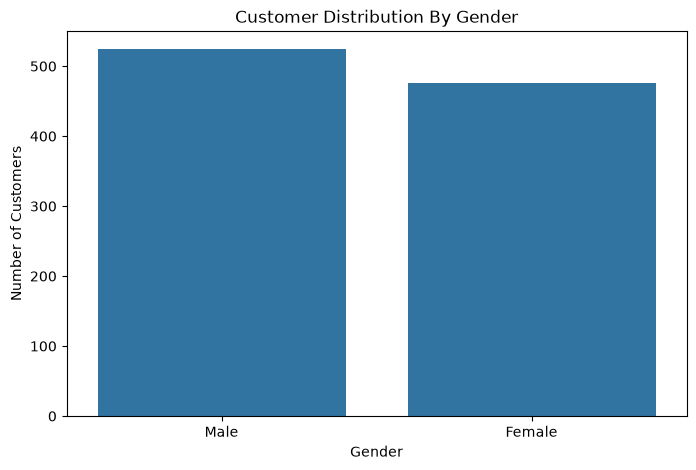

In [20]:
df['Gender'].value_counts()
plt.figure(figsize=(8,5))
sns.countplot( data=df,
               x ='Gender' )
plt.title('Customer Distribution By Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

### Observation
The gender distribution is relatively balanced, suggesting that the retailer serves a broad customer base without
a strong gender concentration.

In [22]:
top_product=(df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(10))
print(top_product)
        

Product Name
Monitor       503
Laptop        464
Keyboard      458
Smartphone    442
Mouse         400
Smartwatch    371
Headphones    370
Name: Quantity, dtype: int64


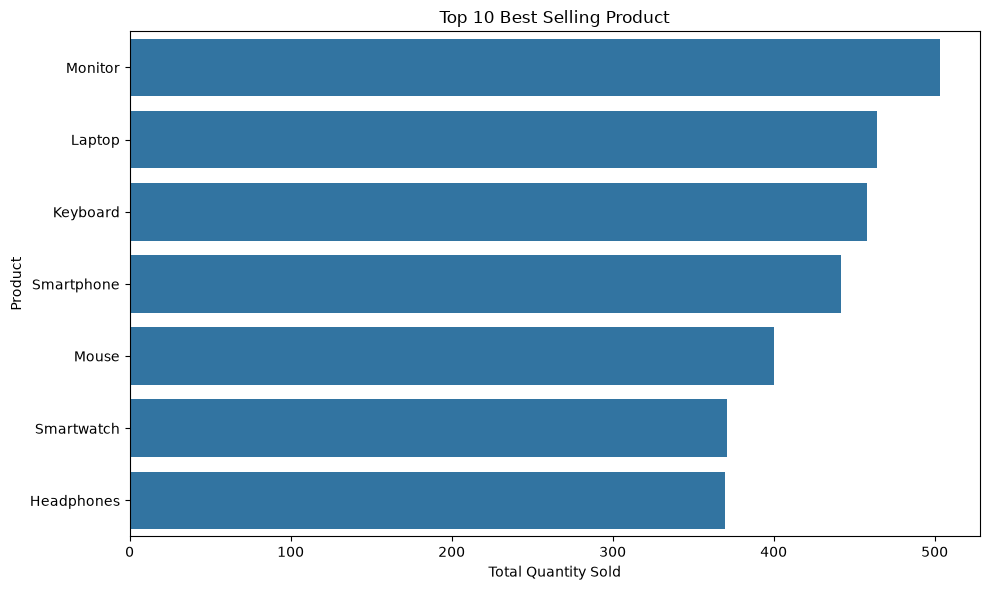

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_product.values,
            y=top_product.index)
plt.title('Top 10 Best Selling Product')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()
            

### Observation
The chart identifies the products with the highest total quantity sold.
These products represent the strongest demand and should receive priority in inventory planning.

In [24]:
category_revenue=(df.groupby('Category')['Total Price'].sum().sort_values(ascending=False))
print(category_revenue)
                  

Category
Electronics    1200500
Wearables        74200
Accessories      71900
Name: Total Price, dtype: int64


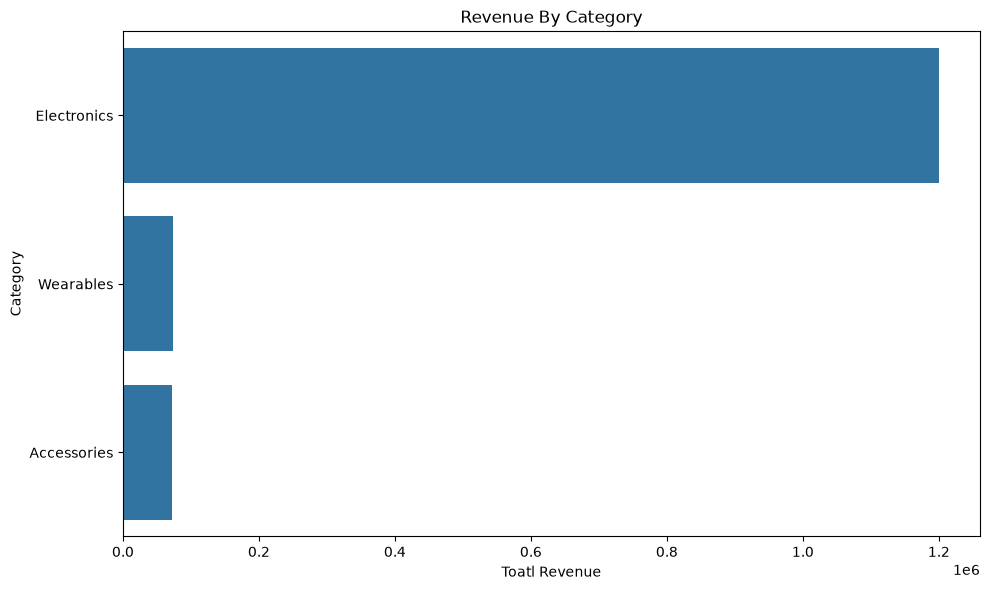

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(x=category_revenue.values,
            y=category_revenue.index)
plt.title('Revenue By Category')
plt.xlabel('Toatl Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

### Observation
Electronics generates the highest revenue among all product categories,
making it an important contributor to overall business performance.

In [26]:
correlation_cols = ['Age','Unit Price','Quantity','Total Price','Shipping Fee']
correlation_matrix = df[correlation_cols].corr()
print(correlation_matrix)

                   Age  Unit Price  Quantity  Total Price  Shipping Fee
Age           1.000000    0.056832  0.014651     0.038775      0.027020
Unit Price    0.056832    1.000000  0.002678     0.824360      0.016851
Quantity      0.014651    0.002678  1.000000     0.360877      0.045812
Total Price   0.038775    0.824360  0.360877     1.000000      0.003249
Shipping Fee  0.027020    0.016851  0.045812     0.003249      1.000000


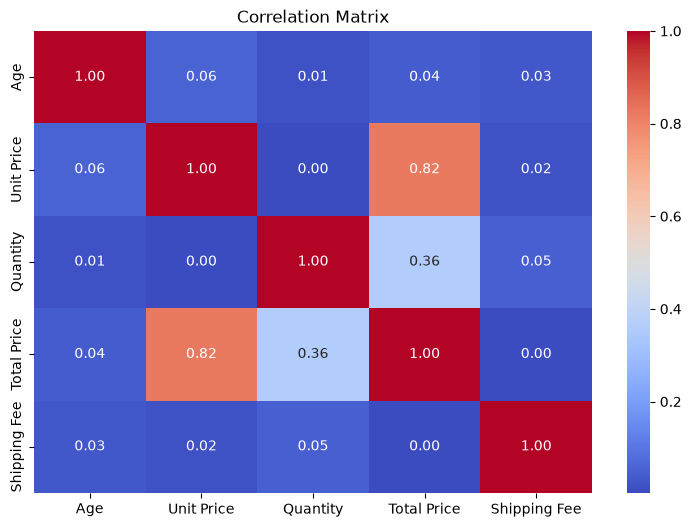

In [27]:
plt.figure(figsize=(9,6))
sns.heatmap(correlation_matrix,annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Observation
The heatmap shows the relationships between numerical variables. 
Total Price has a strong positive correlation with Unit Price (0.82) and a moderate positive correlation with Quantity (0.36),
which is expected as higher quantities and prices contribute to greater transaction values.

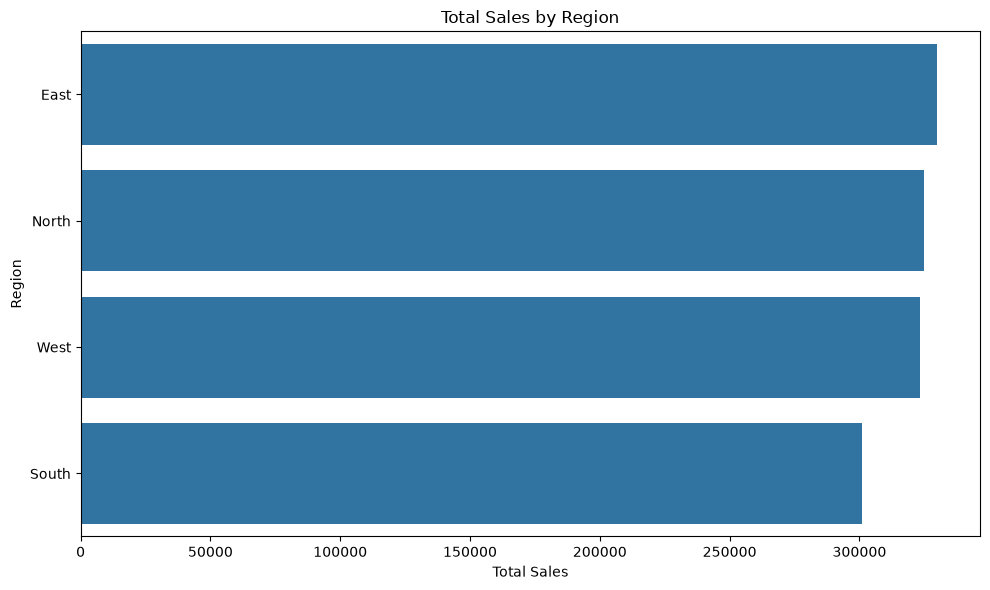

In [30]:
region_sales=(df.groupby('Region')['Total Price'].sum().sort_values(ascending=False))
plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_sales.values,
    y=region_sales.index
)

plt.title("Total Sales by Region")
plt.xlabel("Total Sales")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

### Observation
Sales performance varies across regions. East Region generates the highest revenue, while South Region has the lowest sales.
This may indicate differences in customer demand, market size, or promotional effectiveness.

In [31]:
age_category_sales = pd.pivot_table(
    df,
    values="Total Price",
    index="Age Group",
    columns="Category",
    aggfunc="sum",
    observed=False
)

print(age_category_sales)

Category   Accessories  Electronics  Wearables
Age Group                                     
Under 20          2530        43200        600
20-29             9480       133300      10000
30-39            10640       145500      10400
40-49            11520       173700      11800
50-59            15400       280700      21600
60+              14290       271300      15200


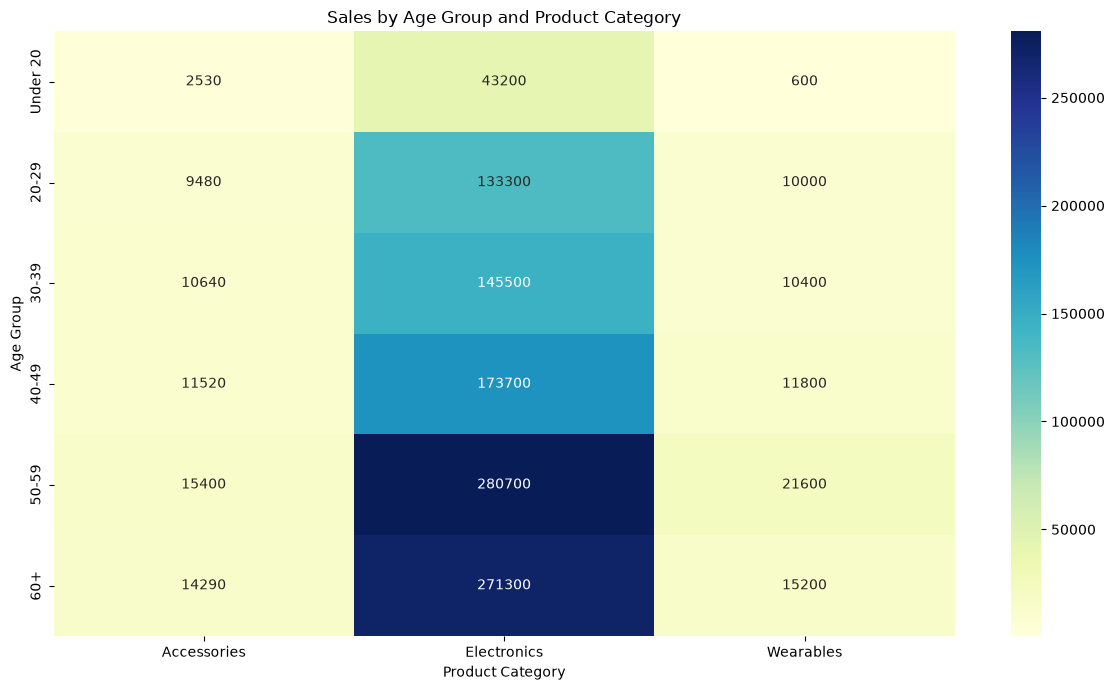

In [33]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    age_category_sales,
    annot=True,
    fmt='.0f',
    cmap="YlGnBu"
)

plt.title('Sales by Age Group and Product Category')
plt.xlabel('Product Category')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

### Observation
Different age groups show different purchasing patterns across productcategories.
This suggests that targeted marketing campaigns could be developed based on customer age and product preferences.

# Conclusion and Business Recommendations

The exploratory data analysis highlights clear patterns in customer behavior, product performance, and sales trends. 
These insights can guide strategic decisions to improve business outcomes.
1. Inventory Planning
Top-selling products such as monitors, laptops, and keyboards consistently drive strong demand. 
Maintaining sufficient inventory levels and buffer stock will help prevent stockouts and lost sales, especially during peak seasons.
    
2. Targeted Marketing
Age groups between 30–59 and 60+ contribute the most to sales, particularly in certain product categories.
Personalized campaigns and promotions tailored to these segments can boost engagement and conversion.
Younger customers (under 20, 20–29) may respond better to digital-first promotions.

3. Regional Strategy
Sales performance varies across regions, with East and North leading while South lags behind.
Region-specific promotions, partnerships, or pricing adjustments should be considered to strengthen demand in weaker markets.

4. Seasonal Sales Planning
Monthly and quarterly trends show strong peaks in Q4, followed by sharp declines in Q1.
Inventory, staffing, and promotional campaigns should be aligned with these seasonal fluctuations. 
Loyalty programs or discount campaigns can help mitigate Q1 slowdowns.

5. Pricing Optimization
The correlation analysis shows a strong relationship between unit price and total price.
This suggests pricing strategies can be optimized to maximize revenue, with a focus on high-margin products.